Mean Squared Error (normalized): 0.0003593337059042521
Root Mean Squared Error (normalized): 0.018956099438023954
Mean Absolute Error (normalized): 0.011455608712801688
R^2 value: 0.9942432085496982
Predictions saved to predictions_svr.csv


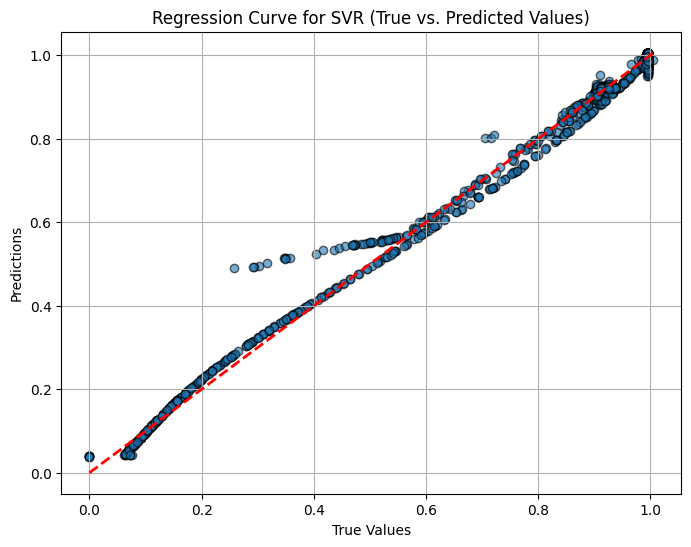

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# Function to read and concatenate CSV files from a directory
def load_data_from_folder(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    data_list = [pd.read_csv(os.path.join(folder_path, file)) for file in csv_files]
    combined_data = pd.concat(data_list, ignore_index=True)
    return combined_data

# Function to normalize features and target
def normalize_data(X, y):
    # Initialize MinMaxScaler for input features and target
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    # Normalize input features (T, L, W)
    X_scaled = scaler_X.fit_transform(X)
    
    # Normalize the target variable (V)
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # Reshape y for the scaler
    
    return X_scaled, y_scaled, scaler_X, scaler_y

# Function to apply SVR
def train_svr(X_train, y_train, kernel='rbf', C=1.0, epsilon=0.1):
    # Initialize the SVR Regressor
    svr_regressor = SVR(kernel=kernel, C=C, epsilon=epsilon)
    
    # Train the model
    svr_regressor.fit(X_train, y_train.ravel())  # ravel() to flatten the target array
    return svr_regressor

# Function to evaluate model performance and plot metrics
def evaluate_model(svr_regressor, X_test, y_test, output_file='predictions_svr.csv'):
    # Make predictions on the test set
    y_pred = svr_regressor.predict(X_test)
    
    # Calculate Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f'Mean Squared Error (normalized): {mse}')
    print(f'Root Mean Squared Error (normalized): {rmse}')
    print(f'Mean Absolute Error (normalized): {mae}')
    print(f'R^2 value: {r2}')

    save_predictions(y_test, y_pred, output_file)
    
    # Plot Regression Curve
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.6)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title('Regression Curve for SVR (True vs. Predicted Values)')
    plt.grid(True)
    plt.show()
    
    return y_pred

# Function to save predictions to a CSV file
def save_predictions(y_test, y_pred, output_file):
    # Create a DataFrame with true and predicted values
    results = pd.DataFrame({
        'True Values': y_test.flatten(),  # Flatten if necessary
        'Predicted Values': y_pred
    })
    
    # Save DataFrame to CSV
    results.to_csv(output_file, index=False)
    print(f'Predictions saved to {output_file}')

# Main execution flow
if __name__ == "__main__":
    training_folder_path = r'C:\Users\ACER\Desktop\as\Training'  # Update with your training folder path
    testing_folder_path = r'C:\Users\ACER\Desktop\as\Testing'    # Update with your testing folder path
    
    # Load the training and testing data
    train_data = load_data_from_folder(training_folder_path)
    test_data = load_data_from_folder(testing_folder_path)
    
    # Optionally reduce dataset size (e.g., for memory management)
    train_data = train_data.sample(frac=0.1, random_state=42)  # Sample 10% of the data
    test_data = test_data.sample(frac=0.1, random_state=42)
    
    # Define input features (T, L, W) and target variable (V) for training and testing data
    X_train = train_data[['T', 'L', 'W']]
    y_train = train_data['V']
    
    X_test = test_data[['T', 'L', 'W']]
    y_test = test_data['V']
    
    # Normalize the input features and target for training
    X_train_scaled, y_train_scaled, scaler_X, scaler_y = normalize_data(X_train, y_train)
    
    # Normalize the input features of the test set using the training scalers (without fitting them again)
    X_test_scaled = scaler_X.transform(X_test)
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))
    
    # Train the SVR model with Radial Basis Function (RBF) kernel
    svr_regressor = train_svr(X_train_scaled, y_train_scaled, kernel='rbf', C=300, epsilon=0.01)
    
    # Evaluate the model
    y_pred = evaluate_model(svr_regressor, X_test_scaled, y_test_scaled)
